In [7]:
import sys
print(sys.executable)

/leonardo/home/userexternal/donutu00/my_venv/bin/python


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
import os
os.getcwd()

'/leonardo_work/OELLM_prod2026/users/donutu00/oellm-autoexp'

In [10]:
def calc_toks_flops(df):
    """Calculate tokens and FLOPs for a given DataFrame of training logs.
     Args:
        df (pd.DataFrame): DataFrame containing training logs with columns 'iteration', 'gbsz', and 'non_embed_params (B)'.
    Returns:
        pd.DataFrame: DataFrame with additional columns for tokens and FLOPs.
    """
    df["tokens (B)"] = df["iteration"] * df["gbsz"] * 4096 / 1e9
    df["compute (exaFLOPs)"] = 6 * df["tokens (B)"] * df["non_embed_params (B)"]
    df["compute (FLOPs)"] = df["compute (exaFLOPs)"] * 1e18
    df.sort_values("tokens (B)", inplace=True)

    return df

In [35]:
def plot_loss_curves(
    models,
    x_axis,
    title_base,
    save_path,
    style_fn=None,
    y_key="lm_loss",
    figsize=(14, 4),
):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    titles = [title_base, f"{title_base} (log)"]

    if x_axis == "tokens":
        x_key = "tokens (B)"
        x_label = "tokens (B)"
    elif x_axis == "compute":
        x_key = "compute (exaFLOPs)"
        x_label = "compute (exaFLOPs)"
    else:
        raise ValueError("x_axis must be either 'tokens' or 'compute'")
    for ax, title in zip(axes, titles):
        for label, data in models.items():
            style = {} if style_fn is None else style_fn(label, data)

            ax.plot(
                data[x_key],
                data[y_key],
                marker="o",
                label=label,
                **style
            )

        ax.set_title(title)
        ax.set_xlabel(x_label)
        ax.set_ylabel("loss")

    axes[1].legend(loc=(1.02, 0.57))
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")

    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

### Opensci reference models

In [11]:
### Loss on independent validation set based on optimal params, manually selected from Niccolo's grids.
opensci_1b = {6: 2.4428, 12: 2.3394, 20: 2.2815, 30: 2.2430, 50: 2.2003,
           80: 2.1646, 120: 2.1368, 200: 2.1095, 300: 2.0861}
opensci_600m = {6: 2.4798, 12: 2.3996, 20: 2.3477, 30: 2.3112, 50: 2.2696,
           80: 2.2357, 120: 2.2110, 200: 2.1802, 300: 2.1599}
opensci_300m = {6: 2.5723, 12: 2.4939, 20: 2.4480, 30: 2.4158, 50: 2.3790,
           80: 2.3457, 120: 2.3210, 200: 2.2952, 300: 2.2769}
opensci_130m = {6: 2.7129, 12: 2.6497, 20: 2.6048, 30: 2.5736, 50: 2.5409,
           80: 2.5162, 120: 2.4975, 200: 2.4772, 300: 2.4647}

The number of parameters and non-embedding parameters are taken from LUMI, arbitrary Niccolo's runs, megatron logs by looking at:
- non-embedding: `Number of parameters in transformer layers in billions:  0.91`
- total (incl. embedding): `Total number of parameters in billions: 0.98`

In [28]:
opensci_130m = pd.DataFrame({
    "iteration": [45777, 91553, 38147, 57221, 95368, 152588, 114441, 190735, 286103],
    "lm_loss": [2.7129, 2.6497, 2.6048, 2.5736, 2.5409, 2.5162, 2.4975, 2.4772, 2.4647],
    "params (B)": [0.12] * 9,
    "non_embed_params (B)": [0.10] * 9,
    "gbsz": [32, 32, 128, 128, 128, 128, 256, 256, 256], 
    "lr": [0.001, 0.001, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002, 0.002],
    "model_name": ["opensci-ref-130M"] * 9,

})
opensci_130m = calc_toks_flops(opensci_130m)
opensci_130m

,iteration,lm_loss,params (B),non_embed_params (B),gbsz,lr,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
0,45777,2.7129,0.12,0.1,32,0.001,opensci-ref-130M,6.000083,3.600050,3.600050e+18
1,91553,2.6497,0.12,0.1,32,0.001,opensci-ref-130M,12.000035,7.200021,7.200021e+18
2,38147,2.6048,0.12,0.1,128,0.002,opensci-ref-130M,20.000014,12.000009,1.200001e+19
3,57221,2.5736,0.12,0.1,128,0.002,opensci-ref-130M,30.000284,18.000170,1.800017e+19
4,95368,2.5409,0.12,0.1,128,0.002,opensci-ref-130M,50.000298,30.000179,3.000018e+19
5,152588,2.5162,0.12,0.1,128,0.002,opensci-ref-130M,80.000057,48.000034,4.800003e+19
6,114441,2.4975,0.12,0.1,256,0.002,opensci-ref-130M,120.000086,72.000052,7.200005e+19
7,190735,2.4772,0.12,0.1,256,0.002,opensci-ref-130M,200.000143,120.000086,1.200001e+20
8,286103,2.4647,0.12,0.1,256,0.002,opensci-ref-130M,300.000739,180.000444,1.800004e+20


In [29]:
opensci_300m = pd.DataFrame({
    "iteration": [22889, 45777, 76294, 114441, 47684, 76294, 114441, 95368, 143052],
    "lm_loss": [2.5723, 2.4939, 2.448, 2.4158, 2.379, 2.3457, 2.321, 2.2952, 2.2769],
    "params (B)": [0.3] * 9,
    "non_embed_params (B)": [0.26] * 9,
    "gbsz": [64, 64, 64, 64, 256, 256, 256, 512, 512], 
    "lr": [0.0005, 0.0005, 0.0005, 0.0005, 0.002, 0.002, 0.002, 0.002, 0.002],
    "model_name": ["opensci-300M"] * 9

})
opensci_300m = calc_toks_flops(opensci_300m)
opensci_300m

,iteration,lm_loss,params (B),non_embed_params (B),gbsz,lr,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
0,22889,2.5723,0.3,0.26,64,0.0005,opensci-300M,6.000214,9.360334,9.360334e+18
1,45777,2.4939,0.3,0.26,64,0.0005,opensci-300M,12.000166,18.720259,1.872026e+19
2,76294,2.4480,0.3,0.26,64,0.0005,opensci-300M,20.000014,31.200022,3.120002e+19
3,114441,2.4158,0.3,0.26,64,0.0005,opensci-300M,30.000022,46.800034,4.680003e+19
4,47684,2.3790,0.3,0.26,256,0.0020,opensci-300M,50.000298,78.000465,7.800046e+19
5,76294,2.3457,0.3,0.26,256,0.0020,opensci-300M,80.000057,124.800089,1.248001e+20
6,114441,2.3210,0.3,0.26,256,0.0020,opensci-300M,120.000086,187.200134,1.872001e+20
7,95368,2.2952,0.3,0.26,512,0.0020,opensci-300M,200.001192,312.001859,3.120019e+20
8,143052,2.2769,0.3,0.26,512,0.0020,opensci-300M,300.001788,468.002789,4.680028e+20


In [30]:
opensci_600m = pd.DataFrame({
    "iteration": [22889, 22889, 38147, 57221, 95368, 152588, 57221, 95368, 143052],
    "lm_loss": [2.4798, 2.3996, 2.3477, 2.3112, 2.2696, 2.2357, 2.211, 2.1802, 2.1599],
    "params (B)": [0.59] * 9,
    "non_embed_params (B)": [0.52] * 9,
    "gbsz": [64, 128, 128, 128, 128, 128, 512, 512, 512], 
    "lr": [0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.002, 0.002, 0.002],
    "model_name": ["opensci-600M"] * 9

})
opensci_600m = calc_toks_flops(opensci_600m)
opensci_600m

,iteration,lm_loss,params (B),non_embed_params (B),gbsz,lr,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
0,22889,2.4798,0.59,0.52,64,0.001,opensci-600M,6.000214,18.720668,1.872067e+19
1,22889,2.3996,0.59,0.52,128,0.001,opensci-600M,12.000428,37.441335,3.744134e+19
2,38147,2.3477,0.59,0.52,128,0.001,opensci-600M,20.000014,62.400045,6.240004e+19
3,57221,2.3112,0.59,0.52,128,0.001,opensci-600M,30.000284,93.600885,9.360088e+19
4,95368,2.2696,0.59,0.52,128,0.001,opensci-600M,50.000298,156.000930,1.560009e+20
5,152588,2.2357,0.59,0.52,128,0.001,opensci-600M,80.000057,249.600179,2.496002e+20
6,57221,2.2110,0.59,0.52,512,0.002,opensci-600M,120.001135,374.403540,3.744035e+20
7,95368,2.1802,0.59,0.52,512,0.002,opensci-600M,200.001192,624.003719,6.240037e+20
8,143052,2.1599,0.59,0.52,512,0.002,opensci-600M,300.001788,936.005578,9.360056e+20


In [31]:
opensci_1b = pd.DataFrame({
    "iteration": [11445, 22889, 38147, 57221, 95368, 152588, 228882, 95368, 143052],
    "lm_loss": [2.4428, 2.3394, 2.2815, 2.243, 2.2003, 2.1646, 2.1368, 2.1095, 2.0861],
    "params (B)": [0.98] * 9,
    "non_embed_params (B)": [0.91] * 9,
    "gbsz": [128, 128, 128, 128, 128, 128, 128, 512, 512], 
    "lr": [0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.0005, 0.002, 0.002],
    "model_name": ["opensci-1B"] * 9

})
opensci_1b = calc_toks_flops(opensci_1b)
opensci_1b

,iteration,lm_loss,params (B),non_embed_params (B),gbsz,lr,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
0,11445,2.4428,0.98,0.91,128,0.0005,opensci-1B,6.000476,32.762600,3.276260e+19
1,22889,2.3394,0.98,0.91,128,0.0005,opensci-1B,12.000428,65.522337,6.552234e+19
2,38147,2.2815,0.98,0.91,128,0.0005,opensci-1B,20.000014,109.200078,1.092001e+20
3,57221,2.2430,0.98,0.91,128,0.0005,opensci-1B,30.000284,163.801549,1.638015e+20
4,95368,2.2003,0.98,0.91,128,0.0005,opensci-1B,50.000298,273.001627,2.730016e+20
5,152588,2.1646,0.98,0.91,128,0.0005,opensci-1B,80.000057,436.800313,4.368003e+20
6,228882,2.1368,0.98,0.91,128,0.0005,opensci-1B,120.000086,655.200470,6.552005e+20
7,95368,2.1095,0.98,0.91,512,0.0020,opensci-1B,200.001192,1092.006508,1.092007e+21
8,143052,2.0861,0.98,0.91,512,0.0020,opensci-1B,300.001788,1638.009762,1.638010e+21


### Replication experiment

In [32]:
### Opensci Original LR 0.002, GBSZ 128 on Leonardo
opensci_120m_50bt_lr002_gbsz128 = pd.DataFrame({
    
    "iteration": [11445, 22889, 38147, 57221, 95368],
    "lm_loss": [2.7296, 2.6512, 2.6048, 2.5736, 2.5409],
    "params (B)": [0.12] * 5,   
    "non_embed_params (B)": [0.10] * 5,
    "gbsz": [128] * 5,
    "lr": [0.002] * 5,
    "model_name": ["opensci-120M-50bt-lr002-gbsz128"] * 5
})
opensci_120m_50bt_lr002_gbsz128 = calc_toks_flops(opensci_120m_50bt_lr002_gbsz128)
opensci_120m_50bt_lr002_gbsz128

,iteration,lm_loss,params (B),non_embed_params (B),gbsz,lr,model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
0,11445,2.7296,0.12,0.1,128,0.002,opensci-120M-50bt-lr002-gbsz128,6.000476,3.600286,3.600286e+18
1,22889,2.6512,0.12,0.1,128,0.002,opensci-120M-50bt-lr002-gbsz128,12.000428,7.200257,7.200257e+18
2,38147,2.6048,0.12,0.1,128,0.002,opensci-120M-50bt-lr002-gbsz128,20.000014,12.000009,1.200001e+19
3,57221,2.5736,0.12,0.1,128,0.002,opensci-120M-50bt-lr002-gbsz128,30.000284,18.000170,1.800017e+19
4,95368,2.5409,0.12,0.1,128,0.002,opensci-120M-50bt-lr002-gbsz128,50.000298,30.000179,3.000018e+19


In [33]:
opensci_replication_120m_50bt_lr002_gbsz128 = pd.read_csv("results/eval_opensci_130M_50BT/val_loss_summary.csv")
opensci_replication_120m_50bt_lr002_gbsz128["gbsz"] = 128
opensci_replication_120m_50bt_lr002_gbsz128["lr"] = 0.002
opensci_replication_120m_50bt_lr002_gbsz128["non_embed_params (B)"] = 0.10
opensci_replication_120m_50bt_lr002_gbsz128["params (B)"] = 0.12
opensci_replication_120m_50bt_lr002_gbsz128["model_name"] = "opensci-replication-120M-50bt-lr002-gbsz128"
opensci_replication_120m_50bt_lr002_gbsz128 = calc_toks_flops(opensci_replication_120m_50bt_lr002_gbsz128)
opensci_replication_120m_50bt_lr002_gbsz128

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,lr,non_embed_params (B),params (B),model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
4,eval_opensci_130M_50BT_lr0.002_gbsz128_beta20....,11445,2.718182,15.15275,128,0.002,0.1,0.12,opensci-replication-120M-50bt-lr002-gbsz128,6.000476,3.600286,3.600286e+18
0,eval_opensci_130M_50BT_lr0.002_gbsz128_beta20....,22889,2.641536,14.03475,128,0.002,0.1,0.12,opensci-replication-120M-50bt-lr002-gbsz128,12.000428,7.200257,7.200257e+18
1,eval_opensci_130M_50BT_lr0.002_gbsz128_beta20....,38147,2.597362,13.42827,128,0.002,0.1,0.12,opensci-replication-120M-50bt-lr002-gbsz128,20.000014,12.000009,1.200001e+19
2,eval_opensci_130M_50BT_lr0.002_gbsz128_beta20....,57221,2.567354,13.03130,128,0.002,0.1,0.12,opensci-replication-120M-50bt-lr002-gbsz128,30.000284,18.000170,1.800017e+19
3,eval_opensci_130M_50BT_lr0.002_gbsz128_beta20....,95368,2.536175,12.63126,128,0.002,0.1,0.12,opensci-replication-120M-50bt-lr002-gbsz128,50.000298,30.000179,3.000018e+19


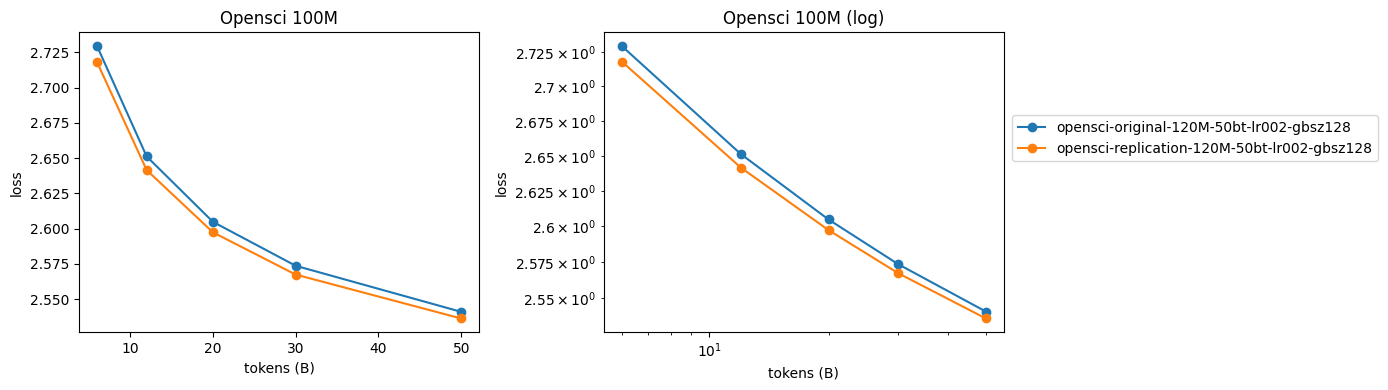

In [43]:
plot_loss_curves(
    models={
        "opensci-original-120M-50bt-lr002-gbsz128": opensci_120m_50bt_lr002_gbsz128,
        "opensci-replication-120M-50bt-lr002-gbsz128": opensci_replication_120m_50bt_lr002_gbsz128,
    },
    x_axis="tokens",
    title_base="Opensci 100M",
    save_path="figures/token_loss_replication_opensci_120m_5bt.png"
)

### No bias experiment

In [42]:
opensci_no_bias_120m_50bt_lr002_gbsz128 = pd.read_csv("results/tests/eval_opensci_no_bias_130M_50BT/val_loss_summary.csv")
opensci_no_bias_120m_50bt_lr002_gbsz128["gbsz"] = 128
opensci_no_bias_120m_50bt_lr002_gbsz128["lr"] = 0.002
opensci_no_bias_120m_50bt_lr002_gbsz128["non_embed_params (B)"] = 0.10
opensci_no_bias_120m_50bt_lr002_gbsz128["params (B)"] = 0.12
opensci_no_bias_120m_50bt_lr002_gbsz128["model_name"] = "opensci-no-bias-120M-50bt-lr002-gbsz128"
opensci_no_bias_120m_50bt_lr002_gbsz128 = calc_toks_flops(opensci_no_bias_120m_50bt_lr002_gbsz128)
opensci_no_bias_120m_50bt_lr002_gbsz128

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,lr,non_embed_params (B),params (B),model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
4,eval_opensci_no_bias_130M_50BT_lr0.002_gbsz128...,11445,2.726390,15.27764,128,0.002,0.1,0.12,opensci-no-bias-120M-50bt-lr002-gbsz128,6.000476,3.600286,3.600286e+18
0,eval_opensci_no_bias_130M_50BT_lr0.002_gbsz128...,22889,2.652258,14.18603,128,0.002,0.1,0.12,opensci-no-bias-120M-50bt-lr002-gbsz128,12.000428,7.200257,7.200257e+18
1,eval_opensci_no_bias_130M_50BT_lr0.002_gbsz128...,38147,2.607003,13.55836,128,0.002,0.1,0.12,opensci-no-bias-120M-50bt-lr002-gbsz128,20.000014,12.000009,1.200001e+19
2,eval_opensci_no_bias_130M_50BT_lr0.002_gbsz128...,57221,2.575242,13.13450,128,0.002,0.1,0.12,opensci-no-bias-120M-50bt-lr002-gbsz128,30.000284,18.000170,1.800017e+19
3,eval_opensci_no_bias_130M_50BT_lr0.002_gbsz128...,95368,2.542319,12.70911,128,0.002,0.1,0.12,opensci-no-bias-120M-50bt-lr002-gbsz128,50.000298,30.000179,3.000018e+19


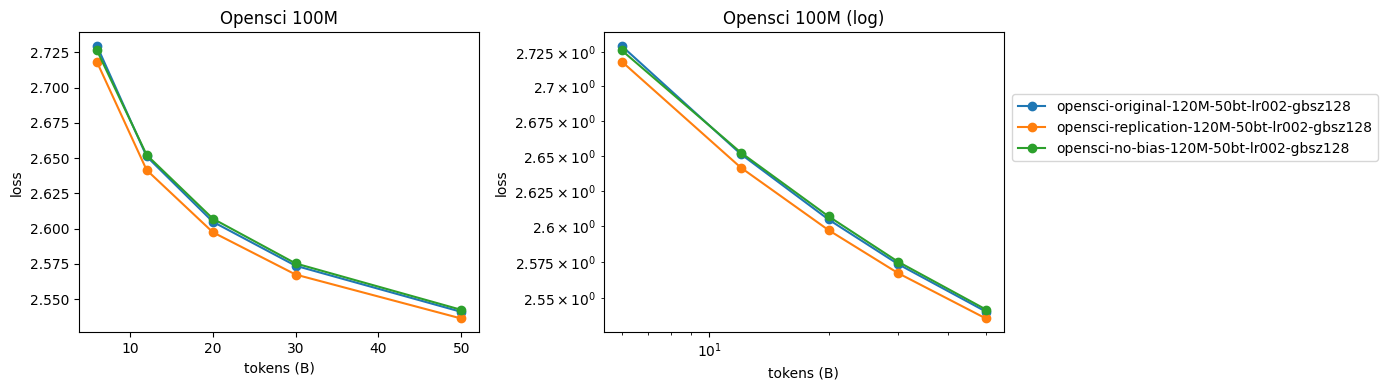

In [44]:
plot_loss_curves(
    models={
        "opensci-original-120M-50bt-lr002-gbsz128": opensci_120m_50bt_lr002_gbsz128,
        "opensci-replication-120M-50bt-lr002-gbsz128": opensci_replication_120m_50bt_lr002_gbsz128,
        "opensci-no-bias-120M-50bt-lr002-gbsz128": opensci_no_bias_120m_50bt_lr002_gbsz128,
    },
    x_axis="tokens",
    title_base="Opensci 100M",
    save_path="figures/token_loss_no_bias_opensci_120m_5bt.png"
)

### GQA experiment

In [45]:
opensci_gqa_120m_50bt_lr002_gbsz128 = pd.read_csv("results/tests/eval_opensci_gqa_130M_50BT/val_loss_summary.csv")
opensci_gqa_120m_50bt_lr002_gbsz128["gbsz"] = 128
opensci_gqa_120m_50bt_lr002_gbsz128["lr"] = 0.002
opensci_gqa_120m_50bt_lr002_gbsz128["non_embed_params (B)"] = 0.09
opensci_gqa_120m_50bt_lr002_gbsz128["params (B)"] = 0.12
opensci_gqa_120m_50bt_lr002_gbsz128["model_name"] = "opensci-gqa-120M-50bt-lr002-gbsz128"
opensci_gqa_120m_50bt_lr002_gbsz128 = calc_toks_flops(opensci_gqa_120m_50bt_lr002_gbsz128)
opensci_gqa_120m_50bt_lr002_gbsz128

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,lr,non_embed_params (B),params (B),model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
4,eval_opensci_gqa_130M_50BT_lr0.002_gbsz128_bet...,11445,2.741812,15.51508,128,0.002,0.09,0.12,opensci-gqa-120M-50bt-lr002-gbsz128,6.000476,3.240257,3.240257e+18
0,eval_opensci_gqa_130M_50BT_lr0.002_gbsz128_bet...,22889,2.664138,14.35557,128,0.002,0.09,0.12,opensci-gqa-120M-50bt-lr002-gbsz128,12.000428,6.480231,6.480231e+18
1,eval_opensci_gqa_130M_50BT_lr0.002_gbsz128_bet...,38147,2.617048,13.69523,128,0.002,0.09,0.12,opensci-gqa-120M-50bt-lr002-gbsz128,20.000014,10.800008,1.080001e+19
2,eval_opensci_gqa_130M_50BT_lr0.002_gbsz128_bet...,57221,2.585113,13.26479,128,0.002,0.09,0.12,opensci-gqa-120M-50bt-lr002-gbsz128,30.000284,16.200153,1.620015e+19
3,eval_opensci_gqa_130M_50BT_lr0.002_gbsz128_bet...,95368,2.551873,12.83111,128,0.002,0.09,0.12,opensci-gqa-120M-50bt-lr002-gbsz128,50.000298,27.000161,2.700016e+19


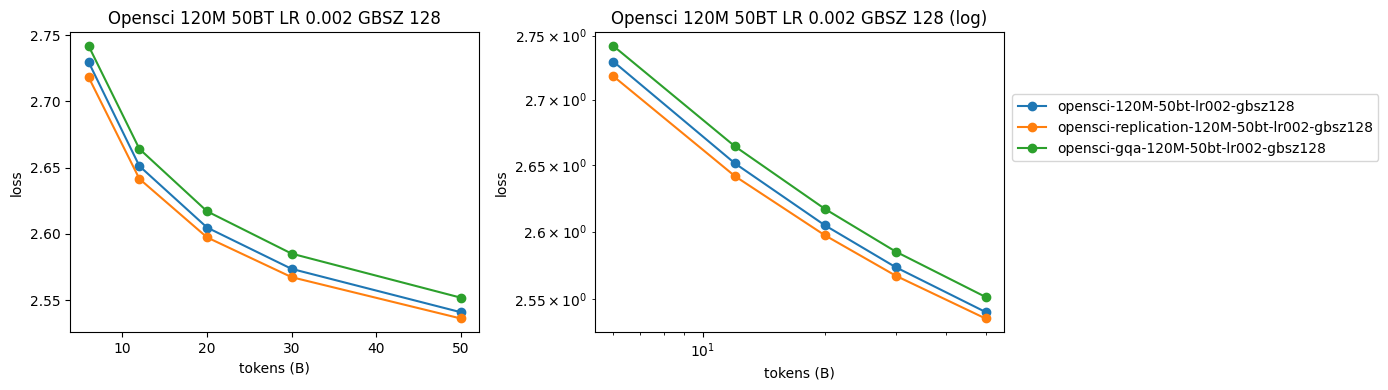

In [46]:
plot_loss_curves(
    models={
        "opensci-120M-50bt-lr002-gbsz128": opensci_120m_50bt_lr002_gbsz128,
        "opensci-replication-120M-50bt-lr002-gbsz128": opensci_replication_120m_50bt_lr002_gbsz128,
        "opensci-gqa-120M-50bt-lr002-gbsz128": opensci_gqa_120m_50bt_lr002_gbsz128,
    },
    x_axis="tokens",
    title_base="Opensci 120M 50BT LR 0.002 GBSZ 128",
    save_path="figures/token_loss_gqa_opensci_120m_5bt.png"
)

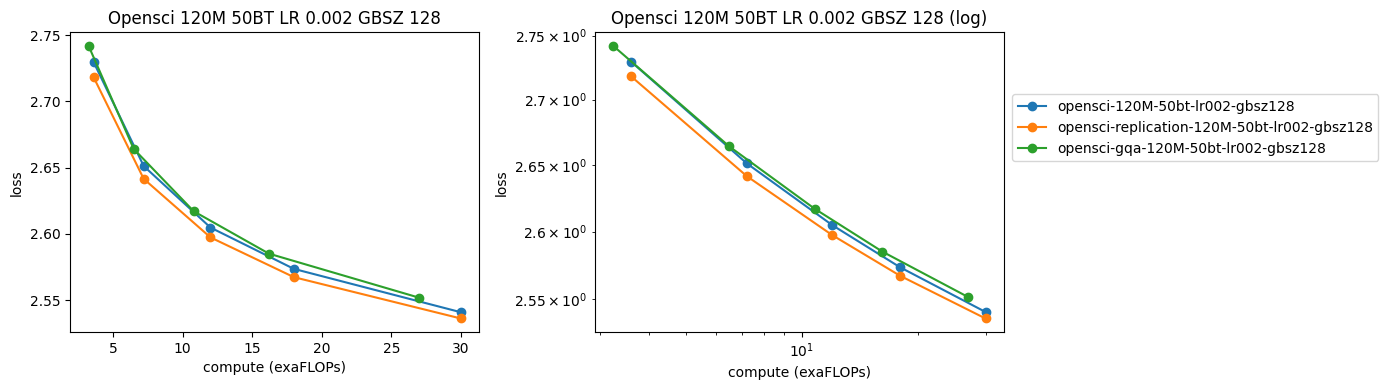

In [47]:
plot_loss_curves(
    models={
        "opensci-120M-50bt-lr002-gbsz128": opensci_120m_50bt_lr002_gbsz128,
        "opensci-replication-120M-50bt-lr002-gbsz128": opensci_replication_120m_50bt_lr002_gbsz128,
        "opensci-gqa-120M-50bt-lr002-gbsz128": opensci_gqa_120m_50bt_lr002_gbsz128,
    },
    x_axis="compute",
    title_base="Opensci 120M 50BT LR 0.002 GBSZ 128",
    save_path="figures/token_loss_gqa_opensci_120m_5bt.png"
)

### Qwen3 experiments

In [50]:
qwen3_80m = pd.read_csv("results/eval_qwen3_150M_gpt_neox/val_loss_summary.csv")
gbsz_tmp = []
lr_tmp = []
for run_name in qwen3_80m.run_name.to_list():
    gbsz = int(run_name.split("gbsz")[1].split("_")[0])
    gbsz_tmp.append(gbsz)

    lr = float(run_name.split("lr")[1].split("_")[0])
    lr_tmp.append(lr)
qwen3_80m["gbsz"] = gbsz_tmp
qwen3_80m["lr"] = lr_tmp
qwen3_80m["non_embed_params (B)"] = 0.08
qwen3_80m["params (B)"] = 0.08
qwen3_80m["model_name"] = "qwen3-150M-gpt-neox"
qwen3_150m = calc_toks_flops(qwen3_80m)
qwen3_150m

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,lr,non_embed_params (B),params (B),model_name,tokens (B),compute (exaFLOPs),compute (FLOPs)
1,eval_dense_qwen3_150M_gpt_neox_lr0.001_gbsz32_...,45777,2.820609,16.78706,32,0.001,0.08,0.08,qwen3-150M-gpt-neox,6.000083,2.880040,2.880040e+18
0,eval_dense_qwen3_150M_gpt_neox_lr0.001_gbsz32_...,91553,2.758214,15.77166,32,0.001,0.08,0.08,qwen3-150M-gpt-neox,12.000035,5.760017,5.760017e+18
2,eval_dense_qwen3_150M_gpt_neox_lr0.002_gbsz128...,38147,2.726732,15.28285,128,0.002,0.08,0.08,qwen3-150M-gpt-neox,20.000014,9.600007,9.600007e+18
3,eval_dense_qwen3_150M_gpt_neox_lr0.002_gbsz128...,57221,2.705373,14.95989,128,0.002,0.08,0.08,qwen3-150M-gpt-neox,30.000284,14.400136,1.440014e+19
4,eval_dense_qwen3_150M_gpt_neox_lr0.002_gbsz128...,95368,2.668249,14.41471,128,0.002,0.08,0.08,qwen3-150M-gpt-neox,50.000298,24.000143,2.400014e+19
5,eval_dense_qwen3_150M_gpt_neox_lr0.002_gbsz128...,152588,2.646245,14.10099,128,0.002,0.08,0.08,qwen3-150M-gpt-neox,80.000057,38.400028,3.840003e+19
6,eval_dense_qwen3_150M_gpt_neox_lr0.002_gbsz256...,114441,2.634049,13.93005,256,0.002,0.08,0.08,qwen3-150M-gpt-neox,120.000086,57.600041,5.760004e+19
7,eval_dense_qwen3_150M_gpt_neox_lr0.002_gbsz256...,190735,2.616503,13.68778,256,0.002,0.08,0.08,qwen3-150M-gpt-neox,200.000143,96.000069,9.600007e+19
8,eval_dense_qwen3_150M_gpt_neox_lr0.002_gbsz256...,286103,2.604685,13.52696,256,0.002,0.08,0.08,qwen3-150M-gpt-neox,300.000739,144.000355,1.440004e+20


In [17]:
qwen3_190m = pd.read_csv("figures/eval_qwen3_300M_gpt_neox/val_loss_summary.csv")
gbsz_tmp = []
for run_name in qwen3_190m.run_name.to_list():
    gbsz = int(run_name.split("gbsz")[1].split("_")[0])
    gbsz_tmp.append(gbsz)
qwen3_190m["gbsz"] = gbsz_tmp
qwen3_190m = adjust_df(qwen3_190m, params=0.19, non_embed_params=0.16)
qwen3_190m

,run_name,iteration,lm_loss,lm_loss_ppl,gbsz,tokens (B),params (B),non_embed_params (B),compute (exaFLOPs),compute (FLOPs)
3,eval_dense_qwen3_300M_gpt_neox_lr0.0005_gbsz64...,22889,2.643505,14.06240,64,6.000214,0.19,0.16,5.760205,5.760205e+18
0,eval_dense_qwen3_300M_gpt_neox_lr0.0005_gbsz64...,45777,2.570333,13.07018,64,12.000166,0.19,0.16,11.520159,1.152016e+19
1,eval_dense_qwen3_300M_gpt_neox_lr0.0005_gbsz64...,76294,2.526704,12.51219,64,20.000014,0.19,0.16,19.200014,1.920001e+19
2,eval_dense_qwen3_300M_gpt_neox_lr0.0005_gbsz64...,114441,2.494958,12.12122,64,30.000022,0.19,0.16,28.800021,2.880002e+19
5,eval_dense_qwen3_300M_gpt_neox_lr0.002_gbsz256...,47684,2.453876,11.63335,256,50.000298,0.19,0.16,48.000286,4.800029e+19
6,eval_dense_qwen3_300M_gpt_neox_lr0.002_gbsz256...,76294,2.424156,11.29269,256,80.000057,0.19,0.16,76.800055,7.680006e+19
4,eval_dense_qwen3_300M_gpt_neox_lr0.002_gbsz256...,114441,2.402606,11.05195,256,120.000086,0.19,0.16,115.200083,1.152001e+20
7,eval_dense_qwen3_300M_gpt_neox_lr0.002_gbsz512...,95368,2.384770,10.85657,512,200.001192,0.19,0.16,192.001144,1.920011e+20
8,eval_dense_qwen3_300M_gpt_neox_lr0.002_gbsz512...,143052,2.368032,10.67636,512,300.001788,0.19,0.16,288.001716,2.880017e+20


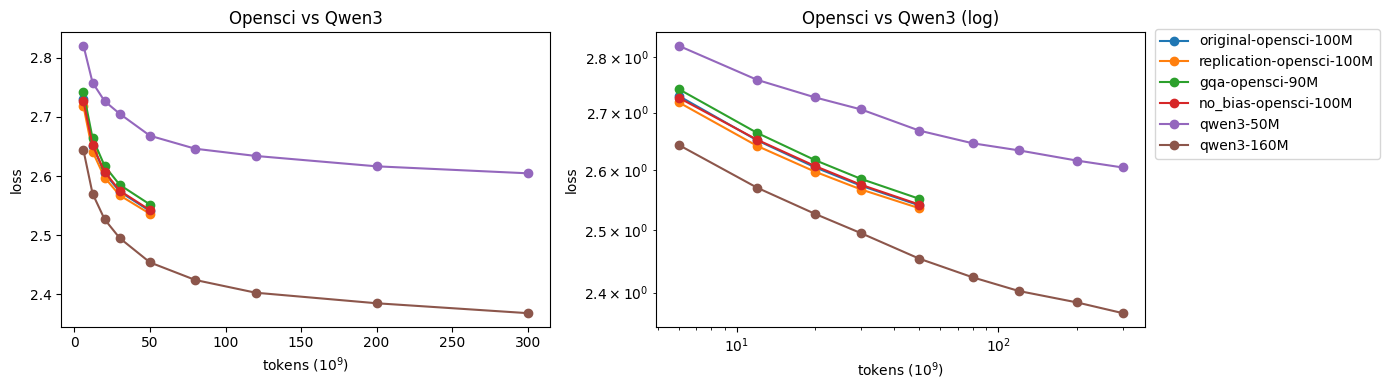

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

models = {
    "original-opensci-100M": opensci_120m_50bt_lr002_gbsz128,
    "replication-opensci-100M": opensci_replication_120m_50bt_lr002_gbsz128,
    "gqa-opensci-90M": opensci_gqa_120m_50bt_lr002_gbsz128,
    "no_bias-opensci-100M": opensci_no_bias_120m_50bt_lr002_gbsz128,
    "qwen3-50M": qwen3_80m,
    "qwen3-160M": qwen3_190m,
}

titles = ["Opensci vs Qwen3", "Opensci vs Qwen3 (log)"]

for ax, title in zip(axes, titles):
    for label, data in models.items():
        ax.plot(data["tokens (B)"], data["lm_loss"], marker='o', label=label)

    ax.set_title(title)
    ax.set_xlabel("tokens ($10^9$)")
    ax.set_ylabel("loss")

axes[1].legend(loc=(1.02, 0.57))
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("figures/token_loss_opensci_qwen3.png")
plt.show()

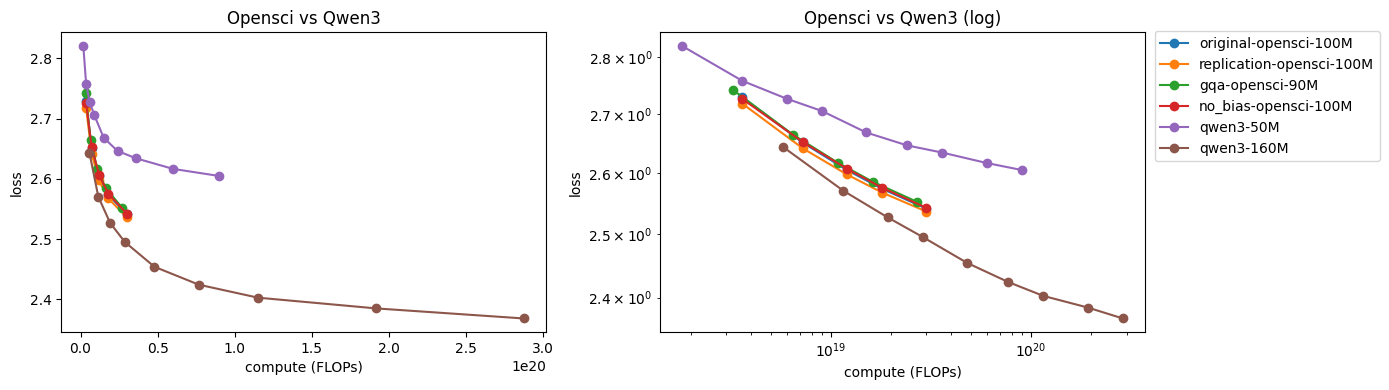

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

models = {
    "original-opensci-100M": opensci_120m_50bt_lr002_gbsz128,
    "replication-opensci-100M": opensci_replication_120m_50bt_lr002_gbsz128,
    "gqa-opensci-90M": opensci_gqa_120m_50bt_lr002_gbsz128,
    "no_bias-opensci-100M": opensci_no_bias_120m_50bt_lr002_gbsz128,
    "qwen3-50M": qwen3_80m,
    "qwen3-160M": qwen3_190m,
}

titles = ["Opensci vs Qwen3", "Opensci vs Qwen3 (log)"]

for ax, title in zip(axes, titles):
    for label, data in models.items():
        ax.plot(data["compute (FLOPs)"], data["lm_loss"], marker='o', label=label)

    ax.set_title(title)
    ax.set_xlabel("compute (FLOPs)")
    ax.set_ylabel("loss")

axes[1].legend(loc=(1.02, 0.57))
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("figures/compute_loss_opensci_qwen3.png")
plt.show()

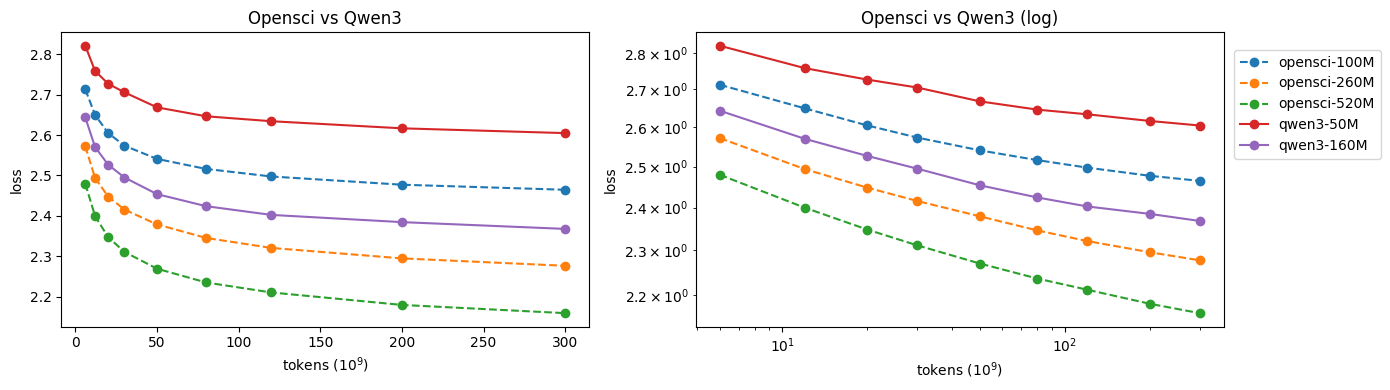

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

models = {
    "opensci-100M": opensci_130m,
    "opensci-260M": opensci_300m,
    "opensci-520M": opensci_600m,

    "qwen3-50M": qwen3_80m,
    "qwen3-160M": qwen3_190m,
}

titles = ["Opensci vs Qwen3", "Opensci vs Qwen3 (log)"]

for ax, title in zip(axes, titles):
    for label, data in models.items():
        if "opensci" in label:
            ax.plot(data["tokens (B)"], data["lm_loss"], marker='o', label=label, linestyle='--')
        else:
            ax.plot(data["tokens (B)"], data["lm_loss"], marker='o', label=label)

    ax.set_title(title)
    ax.set_xlabel("tokens ($10^9$)")
    ax.set_ylabel("loss")

axes[1].legend(loc=(1.02, 0.57))
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("figures/token_loss_opensci_qwen3.png")
plt.show()

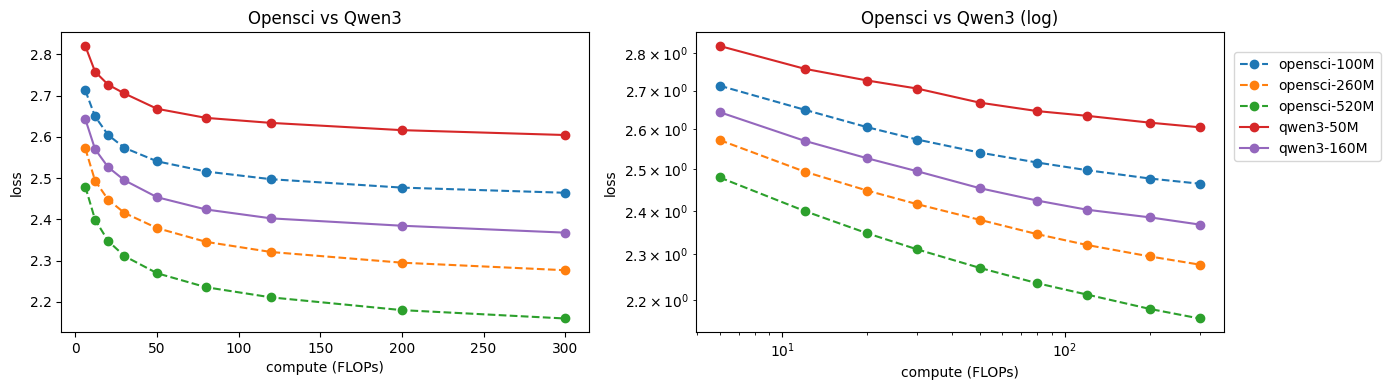

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

models = {
    "opensci-100M": opensci_130m,
    "opensci-260M": opensci_300m,
    "opensci-520M": opensci_600m,

    "qwen3-50M": qwen3_80m,
    "qwen3-160M": qwen3_190m,
}

titles = ["Opensci vs Qwen3", "Opensci vs Qwen3 (log)"]

for ax, title in zip(axes, titles):
    for label, data in models.items():
        if "opensci" in label:
            ax.plot(data["tokens (B)"], data["lm_loss"], marker='o', label=label, linestyle='--')
        else:
            ax.plot(data["tokens (B)"], data["lm_loss"], marker='o', label=label)

    ax.set_title(title)
    ax.set_xlabel("compute (FLOPs)")
    ax.set_ylabel("loss")

axes[1].legend(loc=(1.02, 0.57))
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.savefig("figures/compute_loss_opensci_qwen3.png")
plt.show()